# Stage B: Contamination Dataset Construction

This notebook constructs the training dataset for the EcoBin Stage B contamination classifier. Stage A classified a waste item into one of 30 categories and mapped it to a disposal pathway. Stage B determines whether a recyclable item is contaminated, which contaminant type is present and how severe the contamination is.

The dataset is built entirely from the recyclable images in the Stage A source data. Each source image is copied as-is and labelled **clean**. It is then duplicated three times with synthetic contamination textures composited onto the object at **light**, **medium** and **heavy** severity levels. All three contaminated duplicates of a given source image share the same randomly assigned contaminant type, which ensures subgroup label distributions remain balanced across the dataset.

## Step 1: Setup

### 1.1 Install Dependencies

`rembg` uses a U2-Net neural network to separate the foreground object from the background in each recyclable image. This produces the object mask that restricts contamination textures to the object surface only. `pillow-avif-plugin` registers AVIF format support with Pillow, which is required to open the `.avif` file in the contamination texture library.

In [3]:
!pip install -q "numpy>=2.0.0,<2.4" "scipy>=1.14.0" --force-reinstall

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.

### 1.2 Import Libraries

In [4]:
import io
import math
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndimage
import pillow_avif

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from rembg import remove, new_session

### 1.3 Initialise the rembg Session

`rembg` loads the U2-Net ONNX model from disk each time `remove()` is called without a session argument. Over 10,500 images this adds up to thousands of redundant model loads. Creating one session here and reusing it throughout the pipeline eliminates that overhead. With `rembg[gpu]` installed and a GPU accelerator enabled, ONNX Runtime routes inference through CUDA automatically.

In [5]:
REMBG_SESSION = new_session('u2netp')  # lighter model, 2-3x faster than u2net on CPU
print("rembg session initialised")

  0%|                                              | 0.00/4.57M [00:00<?, ?B/s]

rembg session initialised


### 1.3 Configure Paths, Constants and Recyclable Classes

`DATASET_PATH` points to the same Stage A source dataset used in the waste classification notebook. `TEXTURE_PATH` points to the contamination texture library on Kaggle. `STAGE_B_PATH` is the root directory where the generated dataset will be written. `TEXTURE_CACHE` is a writable directory for caching background-removed texture files, since `/kaggle/input` is read-only.

`CONTAMINATION_LEVELS` maps each severity label to the number of texture patches applied to the object:

| Level | Patches | Description |
|---|---|---|
| light | 1 | A single texture patch applied to one region of the object |
| medium | 2 | Two patches applied to separate regions of the object |
| heavy | 3 | Three patches covering multiple regions of the object |

Each source image produces exactly **one** contaminated copy. Levels are pre-assigned before the loop so that the contaminated set is split evenly: 33% light, 33% medium and 33% heavy. This gives a final dataset of 10,500 clean images and 10,500 contaminated images, balanced 1:1.

`RECYCLABLE_CLASSES` contains the 21 waste classes mapped to `curbside_recycling` or `dropoff_recycling` in the Stage A `DISPOSAL_MAP`. Compost and garbage classes are excluded because they are not recyclable items and contamination detection is not applicable to them.

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_PATH  = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
TEXTURE_PATH  = Path("/kaggle/input/datasets/ragbag84/contamiation-textures-dataset/Contamination Textures Dataset/textures")
STAGE_B_PATH  = Path("/kaggle/working/stage_b")
TEXTURE_CACHE = Path("/kaggle/working/texture_cache")

IMG_SIZE  = 224
MAX_IMAGES = None  # Set to None to run the full dataset

CONTAMINATION_LEVELS = {
    'light':  1,
    'medium': 2,
    'heavy':  3,
}

RECYCLABLE_CLASSES = [
    # Curbside recycling (17 classes)
    'plastic_soda_bottles',
    'aerosol_cans',
    'steel_food_cans',
    'cardboard_boxes',
    'glass_beverage_bottles',
    'plastic_cup_lids',
    'cardboard_packaging',
    'glass_food_jars',
    'aluminum_food_cans',
    'plastic_food_containers',
    'magazines',
    'aluminum_soda_cans',
    'plastic_detergent_bottles',
    'newspaper',
    'office_paper',
    'plastic_water_bottles',
    'glass_cosmetic_containers',
    # Drop-off recycling (4 classes)
    'plastic_shopping_bags',
    'plastic_trash_bags',
    'clothing',
    'shoes',
]

## Step 2: Build the Contamination Texture Pool

### 2.1 Discover Contaminant Types and Texture Images

The texture pool is built by scanning the contamination texture library directory. Each subdirectory represents one contaminant type and contains five source texture images. The pool is a dictionary mapping each contaminant type name to the list of file paths for its textures.

Background-removed PNG versions (identified by the `_nobg` suffix) are excluded from the base file list because they are cached outputs, not source inputs. The `load_texture` function in Step 3.2 resolves the correct version to load for each texture at runtime.

In [7]:
SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.avif'}

def build_texture_pool(texture_path: Path) -> dict:
    pool = {}
    for contaminant_dir in sorted(texture_path.iterdir()):
        if not contaminant_dir.is_dir():
            continue
        textures = sorted(
            f for f in contaminant_dir.iterdir()
            if f.suffix.lower() in SUPPORTED_EXTENSIONS
            and '_nobg' not in f.stem
        )
        if textures:
            pool[contaminant_dir.name] = textures
    return pool

texture_pool = build_texture_pool(TEXTURE_PATH)

print(f"Discovered {len(texture_pool)} contaminant types")
for contaminant, textures in texture_pool.items():
    print(f"  {contaminant:<25} {len(textures)} images")

Discovered 7 contaminant types
  coffee_stains             5 images
  condiment_residue         5 images
  dirt                      5 images
  food_residue              5 images
  grease                    5 images
  paint                     5 images
  wet_paper_pulp            5 images


### 2.2 Display Texture Pool Summary

This cell prints a full inventory of the texture pool, listing each file path under its contaminant type. This confirms that all expected texture files were discovered and that no files were skipped due to unsupported extensions or naming conflicts.

In [8]:
total = sum(len(v) for v in texture_pool.values())
print(f"Contamination Texture Library")
print(f"{'='*50}")
for contaminant, textures in texture_pool.items():
    print(f"\n  {contaminant}")
    for t in textures:
        print(f"    {t.name}")
print(f"\n{'='*50}")
print(f"Total: {len(texture_pool)} types, {total} images")

Contamination Texture Library

  coffee_stains
    coffee_stain_1.jpg
    coffee_stain_2.jpg
    coffee_stain_3.jpg
    coffee_stain_4.jpg
    coffee_stain_5.jpg

  condiment_residue
    condiment_residue_1.jpg
    condiment_residue_2.avif
    condiment_residue_3.jpg
    condiment_residue_4.jpg
    condiment_residue_5.jpg

  dirt
    dirt_1.jpg
    dirt_2.jpg
    dirt_3.png
    dirt_4.png
    dirt_5.jpg

  food_residue
    food_residue_1.jpg
    food_residue_2.jpg
    food_residue_3.jpg
    food_residue_4.jpg
    food_residue_5.jpg

  grease
    grease_1.jpg
    grease_2.jpg
    grease_3.jpg
    grease_4.png
    grease_5.png

  paint
    paint_stain_1.jpg
    paint_stain_2.jpg
    paint_stain_3.jpg
    paint_stain_4.jpg
    paint_stain_5.jpg

  wet_paper_pulp
    wet_paper_pulp_1.jpg
    wet_paper_pulp_2.jpg
    wet_paper_pulp_3.jpg
    wet_paper_pulp_4.jpg
    wet_paper_pulp_5.jpg

Total: 7 types, 35 images


## Step 3: Define Image Processing Functions

Three functions are defined here and called throughout the generation pipeline in Step 4.

### 3.1 Object Segmentation

`get_object_mask` runs `rembg` on a source image to produce a soft float mask that identifies the foreground object. Pixel values close to 1.0 are confidently part of the object. Pixel values close to 0.0 are background.

Two post-processing steps are applied to clean up the raw mask before it is used for compositing:

1. **Morphological closing** fills small holes in the mask that rembg may leave in the interior of the object, for example through transparent or reflective surfaces on glass bottles or plastic bags.
2. **Gaussian blur** feathers the mask edges so the composited contamination fades naturally at the object boundary instead of producing a hard cutline.

In [9]:
def get_object_mask(img: np.ndarray) -> np.ndarray:
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format='JPEG', quality=95)
    output = remove(buf.getvalue(), session=REMBG_SESSION)
    alpha  = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))[:, :, 3]
    alpha  = alpha.astype(np.float32) / 255.0
    binary = ndimage.binary_closing(
        alpha > 0.5, structure=np.ones((5, 5))
    ).astype(np.float32)
    return ndimage.gaussian_filter(binary, sigma=2)

### 3.2 Texture Loading

`load_texture` loads a contamination texture as an RGBA array. The loading strategy depends on the file format:

- **JPEG and AVIF files** cannot store transparency, so `rembg` is always run to remove the white background before the texture can be composited.
- **PNG files** may already contain a transparency channel. If the alpha channel is non-uniform (i.e. the background has already been removed), the file is loaded directly. If the alpha channel is fully opaque (all 255), `rembg` is run.

In both cases, the background-removed result is cached as a `_nobg.png` file in the same directory. On subsequent runs the cached version is loaded immediately without calling `rembg` again, which significantly reduces generation time.

In [10]:
def load_texture(texture_path: Path) -> np.ndarray:
    # Cache lives in /kaggle/working since /kaggle/input is read-only
    cache_path = TEXTURE_CACHE / texture_path.parent.name / (texture_path.stem + '_nobg.png')
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        return np.array(Image.open(cache_path).convert('RGBA'))

    ext = texture_path.suffix.lower()
    needs_removal = True

    if ext == '.png':
        rgba = np.array(Image.open(texture_path).convert('RGBA'))
        # If the alpha channel already has transparency, use it directly
        if rgba[:, :, 3].min() < 255:
            needs_removal = False

    if needs_removal:
        with open(texture_path, 'rb') as f:
            output = remove(f.read())
        rgba = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))

    Image.fromarray(rgba).save(cache_path)
    return rgba

### 3.3 Texture Patch Application

`apply_texture_patch` composites a single contamination texture patch onto the object region of a base image. The texture is randomly augmented before placement so the same source texture file produces a visually distinct patch every time it is used.

The final composite is controlled by three masks multiplied together into a single weight map:

| Mask | Source | Purpose |
|---|---|---|
| Texture alpha | The texture's own RGBA alpha channel | Preserves the stain or residue shape and prevents a rectangular box from being composited |
| Object mask | Output of `get_object_mask` | Restricts the composite to the foreground object so no contamination bleeds onto the background |
| Alpha scalar | Random float in [0.45, 0.75] | Controls the overall opacity of the contamination effect |

The anchor point for each patch is sampled uniformly at random from within the object region, which ensures patches land on the object surface rather than at a fixed location.

In [11]:
def apply_texture_patch(
    base_img: np.ndarray,
    texture_rgba: np.ndarray,
    object_mask: np.ndarray,
    alpha: float = 0.6,
) -> np.ndarray:
    H, W = base_img.shape[:2]

    # Sample a random anchor point from within the object region
    obj_ys, obj_xs = np.where(object_mask > 0.3)
    if len(obj_ys) == 0:
        return base_img
    idx = random.randint(0, len(obj_ys) - 1)
    cy, cx = int(obj_ys[idx]), int(obj_xs[idx])

    # Augment the texture
    tex = Image.fromarray(texture_rgba, 'RGBA')
    tex = tex.rotate(random.uniform(0, 360), expand=True)
    scale = random.uniform(0.25, 0.60)
    tex = tex.resize((max(1, int(W * scale)), max(1, int(H * scale))), Image.LANCZOS)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_TOP_BOTTOM)

    tex_arr = np.array(tex)
    th, tw = tex_arr.shape[:2]

    # Compute placement coordinates centered on the anchor
    x1, y1 = cx - tw // 2, cy - th // 2
    x2, y2 = x1 + tw, y1 + th

    # Clip to image bounds
    ix1, iy1 = max(0, x1), max(0, y1)
    ix2, iy2 = min(W, x2), min(H, y2)

    if ix2 <= ix1 or iy2 <= iy1:
        return base_img

    # Corresponding slice in the texture array
    sx1 = ix1 - x1
    sy1 = iy1 - y1
    sx2 = sx1 + (ix2 - ix1)
    sy2 = sy1 + (iy2 - iy1)
    tex_slice = tex_arr[sy1:sy2, sx1:sx2]

    # Three-way weight: texture alpha x object mask x user alpha
    tex_a  = tex_slice[:, :, 3].astype(np.float32) / 255.0
    obj_a  = object_mask[iy1:iy2, ix1:ix2]
    weight = tex_a * obj_a * alpha

    # Composite
    result  = base_img.astype(np.float32)
    region  = result[iy1:iy2, ix1:ix2]
    tex_rgb = tex_slice[:, :, :3].astype(np.float32)
    result[iy1:iy2, ix1:ix2] = (
        region * (1 - weight[..., np.newaxis]) + tex_rgb * weight[..., np.newaxis]
    )
    return np.clip(result, 0, 255).astype(np.uint8)

## Step 4: Generate the Stage B Dataset

### 4.1 Build the Output Directory Structure

Only the contaminated images need to be written to disk. Clean images are referenced directly from the original Stage A dataset in the manifest, so no `clean/` directory is created. Each contaminated subdirectory encodes both the contaminant subgroup and the severity level.

```
stage_b/
└── contaminated/
    ├── coffee_stains/
    │   ├── light/
    │   ├── medium/
    │   └── heavy/
    ├── dirt/
    │   ├── light/
    │   ├── medium/
    │   └── heavy/
    └── ... (one folder per contaminant type)
```

Any existing Stage B output is cleared before the pipeline runs to ensure a clean state.

In [12]:
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print("Cleared existing Stage B directory")

for contaminant in texture_pool:
    for level in CONTAMINATION_LEVELS:
        (STAGE_B_PATH / 'contaminated' / contaminant / level).mkdir(parents=True, exist_ok=True)

print("Output directory structure created")
print(f"  {STAGE_B_PATH / 'contaminated'}")

Output directory structure created
  /kaggle/working/stage_b/contaminated


### 4.2 Run the Generation Pipeline

All source images are collected upfront and a level is pre-assigned to each one before the loop begins. Pre-assigning ensures the contaminated set is exactly balanced: `ceil(n / 3)` images per level, trimmed to the total image count and shuffled so no class is biased toward a particular level.

For each source image the pipeline executes three steps:

1. **Load and resize** the source image to 224x224 pixels to match the Stage A input size.
2. **Record the clean label** by writing the original dataset path directly into the manifest. No copy is made.
3. **Generate one contaminated copy** using the pre-assigned level. A contaminant type is sampled at random, N texture patches are applied using `apply_texture_patch`, and the result is saved into `contaminated/{contaminant_type}/{level}/`.

In [13]:
records = []
contaminant_types = list(texture_pool.keys())

# Collect all source images across every recyclable class
all_images = []
for class_name in RECYCLABLE_CLASSES:
    class_dir = DATASET_PATH / class_name
    if not class_dir.exists():
        print(f"WARNING: {class_name} not found in dataset, skipping")
        continue
    for img_path in class_dir.rglob('*'):
        if img_path.is_file():
            all_images.append((class_name, img_path))

# Apply MAX_IMAGES limit if set
if MAX_IMAGES is not None:
    all_images = all_images[:MAX_IMAGES]

n = len(all_images)

# Pre-assign balanced levels: ceil(n/3) of each, trimmed to n, then shuffled
n_per_level = math.ceil(n / 3)
level_pool  = (['light'] * n_per_level + ['medium'] * n_per_level + ['heavy'] * n_per_level)[:n]
random.shuffle(level_pool)

print(f"Source images : {n:,}")
print(f"  light       : {level_pool.count('light'):,}")
print(f"  medium      : {level_pool.count('medium'):,}")
print(f"  heavy       : {level_pool.count('heavy'):,}")
print(f"Expected total: {n * 2:,}  ({n:,} clean + {n:,} contaminated)\n")

for (class_name, img_path), level in tqdm(
    zip(all_images, level_pool), total=n, desc="Generating"
):
    unique_stem = f"{img_path.parent.name}_{img_path.stem}"

    # Load and resize source image
    base_img = np.array(
        Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    )

    # Record clean label pointing directly to the original dataset image
    records.append({
        'image_path':   str(img_path),
        'label':        'clean',
        'subgroup':     'none',
        'level':        'none',
        'source_class': class_name,
    })

    # Generate object mask once per source image
    mask = get_object_mask(base_img)

    # Sample a contaminant type and apply N patches for the assigned level
    contaminant_type   = random.choice(contaminant_types)
    available_textures = texture_pool[contaminant_type]
    n_patches          = CONTAMINATION_LEVELS[level]

    result_img = base_img.copy()
    for _ in range(n_patches):
        tex_path   = random.choice(available_textures)
        texture    = load_texture(tex_path)
        alpha      = random.uniform(0.45, 0.75)
        result_img = apply_texture_patch(result_img, texture, mask, alpha=alpha)

    out_dir  = STAGE_B_PATH / 'contaminated' / contaminant_type / level / class_name
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{unique_stem}_{contaminant_type}_{level}.jpg"
    Image.fromarray(result_img).save(out_path, quality=95)
    records.append({
        'image_path':   str(out_path),
        'label':        'contaminated',
        'subgroup':     contaminant_type,
        'level':        level,
        'source_class': class_name,
    })

print(f"\nGeneration complete: {n:,} source images → {len(records):,} total images")

Source images : 10,500
  light       : 3,500
  medium      : 3,500
  heavy       : 3,500
Expected total: 21,000  (10,500 clean + 10,500 contaminated)



Generating:   0%|          | 0/10500 [00:00<?, ?it/s]Downloading data from 'https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx' to file '/root/.u2net/u2net.onnx'.


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Generating: 100%|██████████| 10500/10500 [13:32<00:00, 12.92it/s]


Generation complete: 10,500 source images → 21,000 total images


## Step 5: Build the Stage B Manifest

The manifest is a CSV file that records every image in the dataset alongside its full label information. It decouples the Stage B dataloader from the directory structure so either the file paths or the CSV columns can be used independently to drive training.

| Column | Values | Description |
|---|---|---|
| image_path | string | File path relative to `stage_b/` |
| label | `clean`, `contaminated` | Binary classification target for Stage B |
| subgroup | contaminant type or `none` | Which contaminant type was applied |
| level | `light`, `medium`, `heavy` or `none` | Contamination severity |
| source_class | waste class name | Original Stage A waste class the image came from |

In [14]:
df = pd.DataFrame(records)

manifest_path = STAGE_B_PATH / 'stage_b_manifest.csv'
df.to_csv(manifest_path, index=False)

print(f"Manifest saved to {manifest_path}")
print(f"Total images: {len(df):,}")
print(f"\nSample rows:")
print(df.head(8).to_string(index=False))

Manifest saved to /kaggle/working/stage_b/stage_b_manifest.csv
Total images: 21,000

Sample rows:
                                                                                                                                image_path        label          subgroup  level         source_class
  /kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images/plastic_soda_bottles/default/Image_1.png        clean              none   none plastic_soda_bottles
                 /kaggle/working/stage_b/contaminated/wet_paper_pulp/medium/plastic_soda_bottles/default_Image_1_wet_paper_pulp_medium.jpg contaminated    wet_paper_pulp medium plastic_soda_bottles
/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images/plastic_soda_bottles/default/Image_213.png        clean              none   none plastic_soda_bottles
                     /kaggle/working/stage_b/contaminated/food_residue/light/plastic_soda_bottles/default_Imag

## Step 6: Audit the Dataset

With the manifest built, we can audit the dataset to verify that the generation pipeline produced the expected number of images per label, subgroup and severity level.

### 6.1 Label Distribution

This cell prints the total image count split by binary label. The clean and contaminated sets should be in a 1:3 ratio because each source image produces one clean copy and three contaminated copies (one per severity level).

In [15]:
label_counts = df['label'].value_counts()

print("Label Distribution")
print("=" * 40)
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(df):>7,}")

Label Distribution
  clean                 10,500  (50.0%)
  contaminated          10,500  (50.0%)
----------------------------------------
  Total                 21,000


### 6.2 Subgroup Distribution

This cell prints the image count per contaminant type within the contaminated set. Because contaminant type is assigned uniformly at random per source image and fixed across all three levels, each type should receive approximately equal representation (roughly 1/7 of the contaminated set).

In [16]:
contaminated_df = df[df['label'] == 'contaminated']
subgroup_counts = contaminated_df['subgroup'].value_counts().sort_index()

print("Subgroup Distribution (contaminated images only)")
print("=" * 50)
for subgroup, count in subgroup_counts.items():
    pct = count / len(contaminated_df) * 100
    print(f"  {subgroup:<28} {count:>7,}  ({pct:.1f}%)")
print("-" * 50)
print(f"  {'Total':<28} {len(contaminated_df):>7,}")

Subgroup Distribution (contaminated images only)
  coffee_stains                  1,467  (14.0%)
  condiment_residue              1,553  (14.8%)
  dirt                           1,472  (14.0%)
  food_residue                   1,545  (14.7%)
  grease                         1,557  (14.8%)
  paint                          1,463  (13.9%)
  wet_paper_pulp                 1,443  (13.7%)
--------------------------------------------------
  Total                         10,500


### 6.3 Level Distribution

This cell prints the image count per severity level within the contaminated set. Each level is generated once per source image so the three levels should have identical counts.

In [17]:
level_counts = contaminated_df['level'].value_counts()
level_order  = ['light', 'medium', 'heavy']

print("Level Distribution (contaminated images only)")
print("=" * 40)
for level in level_order:
    count = level_counts.get(level, 0)
    pct = count / len(contaminated_df) * 100
    print(f"  {level:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(contaminated_df):>7,}")

Level Distribution (contaminated images only)
  light                  3,500  (33.3%)
  medium                 3,500  (33.3%)
  heavy                  3,500  (33.3%)
----------------------------------------
  Total                 10,500


### 6.4 Summary Bar Charts

This cell plots the label, subgroup and level distributions side by side and saves the figure to `/kaggle/working/stage_b_audit.png`.

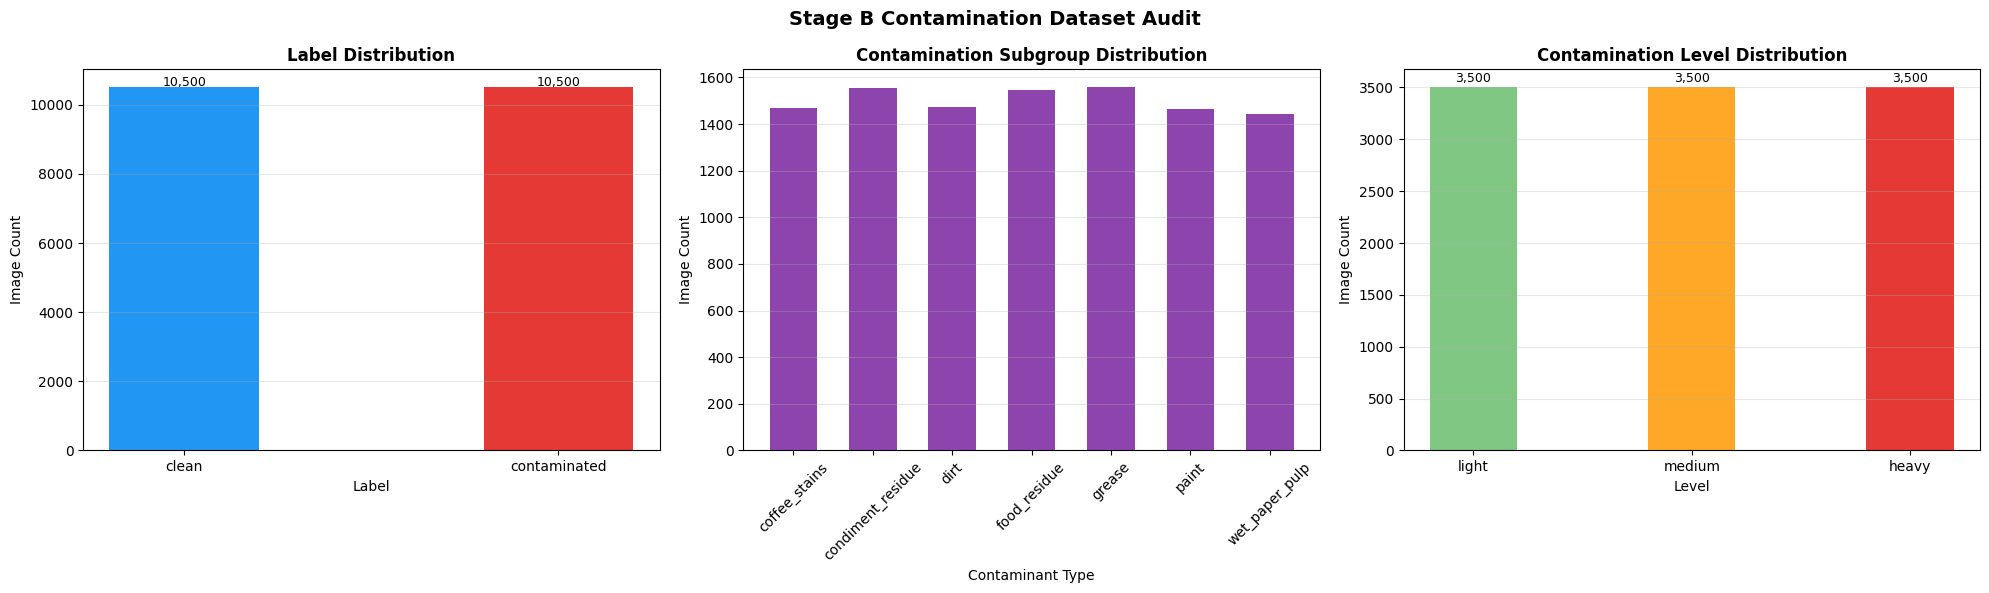

Saved to /kaggle/working/stage_b_audit.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Label distribution
axes[0].bar(
    label_counts.index, label_counts.values,
    color=['#2196F3', '#E53935'], width=0.4
)
axes[0].set_title('Label Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label', fontsize=10)
axes[0].set_ylabel('Image Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

# Subgroup distribution
axes[1].bar(
    subgroup_counts.index, subgroup_counts.values,
    color='#8E44AD', width=0.6
)
axes[1].set_title('Contamination Subgroup Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Contaminant Type', fontsize=10)
axes[1].set_ylabel('Image Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Level distribution
level_vals   = [level_counts.get(l, 0) for l in level_order]
level_colors = ['#81C784', '#FFA726', '#E53935']
axes[2].bar(level_order, level_vals, color=level_colors, width=0.4)
axes[2].set_title('Contamination Level Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Level', fontsize=10)
axes[2].set_ylabel('Image Count', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(level_vals):
    axes[2].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

plt.suptitle('Stage B Contamination Dataset Audit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stage_b_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to /kaggle/working/stage_b_audit.png")

### 6.5 Visual Sample Audit

This cell randomly samples 10 images from the generated dataset and displays them in two rows of five. Each image is labelled with its binary label, subgroup and severity level so the compositing quality can be inspected visually before committing to the full generation run.

Clean rows   : 10500
Cont rows    : 10500
Pairs found  : 5


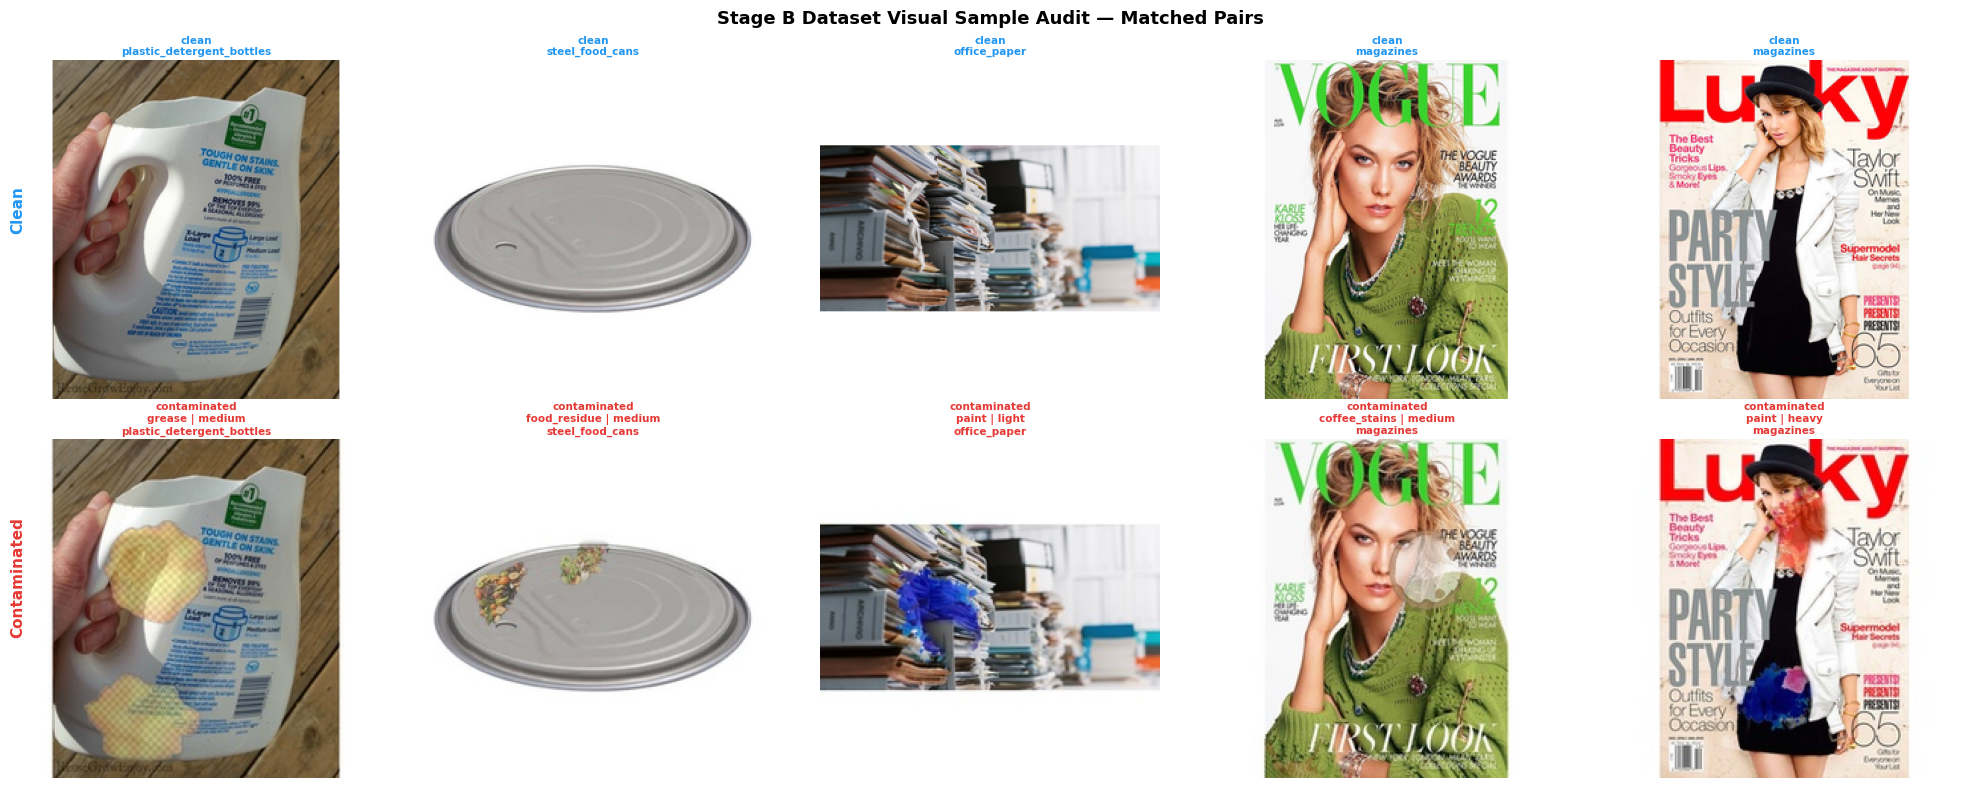

Saved to /kaggle/working/stage_b_visual_audit.png


In [19]:
clean_rows = df[df['label'] == 'clean'].reset_index(drop=True)
cont_rows  = df[df['label'] == 'contaminated'].reset_index(drop=True)

sample_idx = random.sample(range(len(cont_rows)), min(5, len(cont_rows)))
pairs = [(clean_rows.iloc[i], cont_rows.iloc[i]) for i in sample_idx]

print(f"Clean rows   : {len(clean_rows)}")
print(f"Cont rows    : {len(cont_rows)}")
print(f"Pairs found  : {len(pairs)}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, (clean_row, cont_row) in enumerate(pairs):
    axes[0, col].imshow(Image.open(clean_row['image_path']).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(f"clean\n{clean_row['source_class']}", fontsize=7.5,
                            color='#2196F3', fontweight='bold', pad=4)

    axes[1, col].imshow(Image.open(cont_row['image_path']).convert('RGB'))
    axes[1, col].axis('off')
    axes[1, col].set_title(
        f"contaminated\n{cont_row['subgroup']} | {cont_row['level']}\n{cont_row['source_class']}",
        fontsize=7.5, color='#E53935', fontweight='bold', pad=4
    )

fig.text(0.01, 0.73, 'Clean',        va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#2196F3')
fig.text(0.01, 0.27, 'Contaminated', va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#E53935')

plt.suptitle('Stage B Dataset Visual Sample Audit — Matched Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stage_b_visual_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /kaggle/working/stage_b_visual_audit.png")

### 6.6 Save Synthetic Recyclable Contamination Dataset

In [23]:
import os
import shutil
from pathlib import Path
from tqdm import tqdm
RECYCLABLE_CLASSES = [
    'plastic_soda_bottles', 'aerosol_cans', 'steel_food_cans',
    'cardboard_boxes', 'glass_beverage_bottles', 'plastic_cup_lids',
    'cardboard_packaging', 'glass_food_jars', 'aluminum_food_cans',
    'plastic_food_containers', 'magazines', 'aluminum_soda_cans',
    'plastic_detergent_bottles', 'newspaper', 'office_paper',
    'plastic_water_bottles', 'glass_cosmetic_containers',
    'plastic_shopping_bags', 'plastic_trash_bags', 'clothing', 'shoes',
]
BASE   = Path('/kaggle/working/Synthetic Recyclable Contamination Dataset/images')
CLEAN  = BASE / 'clean'
CONTAM = BASE / 'contaminated'
if BASE.exists():
    shutil.rmtree(BASE)
BASE.mkdir(parents=True)
# --- Clean images ---
# Preserve the full relative path under each class dir to avoid name collisions
# (the source dataset stores images as {class}/default/Image_N.png)
SRC_DATASET = Path('/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images')
print("Copying clean images...")
total_clean = 0
for cls in tqdm(RECYCLABLE_CLASSES):
    src_cls = SRC_DATASET / cls
    dst_cls = CLEAN / cls
    if not src_cls.exists():
        print(f"  WARNING: {cls} not found — skipping")
        continue
    for f in src_cls.rglob('*'):
        if not f.is_file():
            continue
        dst_file = dst_cls / f.relative_to(src_cls)
        dst_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dst_file)
        total_clean += 1
# --- Contaminated images ---
# Flatten from contaminated/{subgroup}/{level}/{class}/ → contaminated/{class}/
# so the structure mirrors the clean side for training dataloaders
SRC_CONTAM = Path('/kaggle/working/stage_b/contaminated')
print("\nCopying contaminated images...")
total_contam = 0
for img_file in tqdm(list(SRC_CONTAM.rglob('*.jpg'))):
    # path is: contaminated/{subgroup}/{level}/{class}/{filename}.jpg
    cls = img_file.parent.name
    dst_file = CONTAM / cls / img_file.name
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_file, dst_file)
    total_contam += 1
# --- Manifest ---
shutil.copy2(
    '/kaggle/working/stage_b/stage_b_manifest.csv',
    BASE.parent / 'stage_b_manifest.csv'
)
# --- Summary ---
print(f"\nFinal directory structure:")
print(f"Synthetic Recyclable Contamination Dataset/")
print(f"├── stage_b_manifest.csv")
print(f"└── images/")
print(f"    ├── clean/          {total_clean:>6,} images across {len(list(CLEAN.iterdir()))} classes")
print(f"    └── contaminated/   {total_contam:>6,} images across {len(list(CONTAM.iterdir()))} classes")

Copying clean images...


100%|██████████| 21/21 [00:34<00:00,  1.64s/it]



Copying contaminated images...


100%|██████████| 10500/10500 [00:01<00:00, 6241.02it/s]


Final directory structure:
Synthetic Recyclable Contamination Dataset/
├── stage_b_manifest.csv
└── images/
    ├── clean/          10,500 images across 21 classes
    └── contaminated/   10,500 images across 21 classes


In [ ]:
import zipfile
from pathlib import Path
from tqdm import tqdm

DATASET_DIR = Path('/kaggle/working/Synthetic Recyclable Contamination Dataset')
ZIP_PATH    = Path('/kaggle/working/synthetic_recyclable_contamination_dataset.zip')

print("Zipping dataset...")
all_files = [f for f in DATASET_DIR.rglob('*') if f.is_file()]
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in tqdm(all_files):
        zf.write(f, f.relative_to(DATASET_DIR.parent))

size_mb = ZIP_PATH.stat().st_size / 1024 ** 2
print(f"\nArchive ready: {ZIP_PATH.name}  ({size_mb:.1f} MB)")
print("Go to the Output panel on the right side of the Kaggle editor and click the file to download it.")